### DBSCAN vs K-means

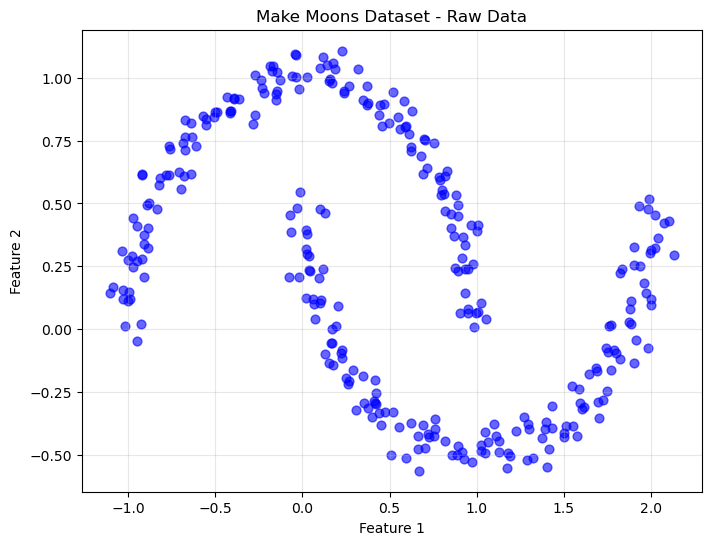

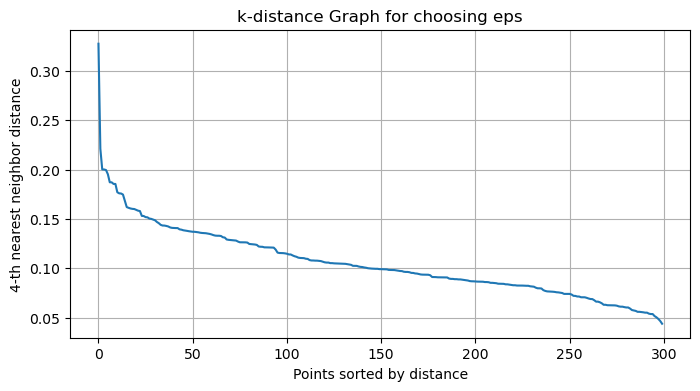

距离统计: 最小值=0.0437, 最大值=0.3275, 中位数=0.0990
建议: 找曲线拐点（膝盖处）对应的 Y 值作为 eps

========== 聚类结果 ==========
eps = 0.15, min_samples = 4
发现的簇数量: 12
被标记为噪声的点数: 9 (占比 3.00%)


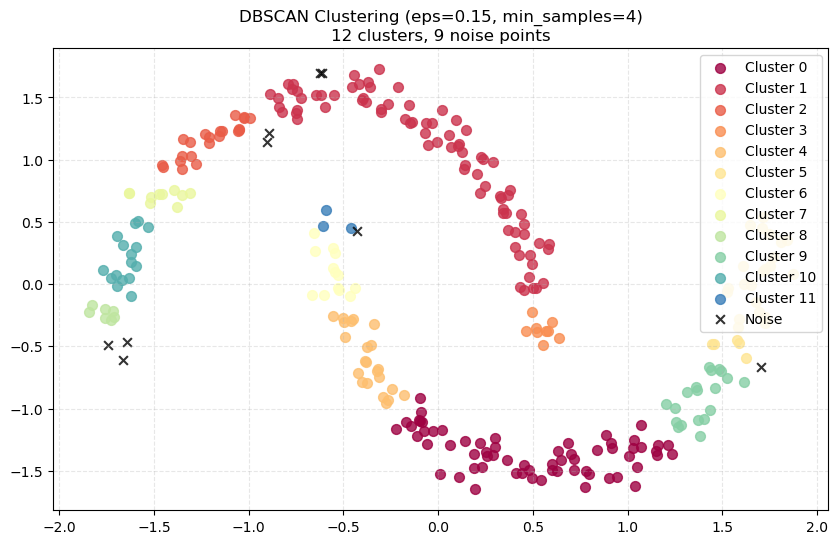


========== 尝试不同 eps 值对比 ==========
eps=0.05: 簇数=3, 噪声点数=288
eps=0.10: 簇数=27, 噪声点数=88
eps=0.15: 簇数=12, 噪声点数=9
eps=0.20: 簇数=2, 噪声点数=0
eps=0.30: 簇数=2, 噪声点数=0
eps=0.50: 簇数=2, 噪声点数=0


In [2]:
# ========== 1. 导入必要的库 ==========
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_circles
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

# ========== 2. 生成演示数据（月牙形 + 环形，DBSCAN 的经典优势场景）==========
# 生成两个半月牙形状的数据（K-Means 搞不定的典型）
X, y_true = make_moons(n_samples=300, noise=0.05, random_state=42)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], color='blue', alpha=0.6, s=40)

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Make Moons Dataset - Raw Data')
plt.grid(True, alpha=0.3)
plt.show()


# 再加一个环形数据（可选，注释掉可换）
# X, y_true = make_circles(n_samples=300, factor=0.5, noise=0.05, random_state=42)

# 标准化（非常重要！因为 DBSCAN 基于距离，尺度不一致会出问题）
X = StandardScaler().fit_transform(X)

# ========== 3. 调参辅助：画 k-distance 图来选 eps ==========
def plot_k_distance(X, minPts=4):
    """
    画出 k-距离图，用于肉眼选 eps 的拐点
    """
    neighbors = NearestNeighbors(n_neighbors=minPts)
    neighbors_fit = neighbors.fit(X)
    distances, indices = neighbors_fit.kneighbors(X)
    
    # 取第 minPts-1 列（即第 minPts 近的距离），从大到小排序
    k_distances = np.sort(distances[:, minPts-1])[::-1]
    
    plt.figure(figsize=(8, 4))
    plt.plot(k_distances)
    plt.xlabel('Points sorted by distance')
    plt.ylabel(f'{minPts}-th nearest neighbor distance')
    plt.title('k-distance Graph for choosing eps')
    plt.grid(True)
    plt.show()
    
    # 打印一些统计值帮你参考
    print(f"距离统计: 最小值={k_distances.min():.4f}, 最大值={k_distances.max():.4f}, 中位数={np.median(k_distances):.4f}")
    print("建议: 找曲线拐点（膝盖处）对应的 Y 值作为 eps")

# 先画图看看，再决定 eps
minPts = 4  # 通常 2D 数据设 4~6
plot_k_distance(X, minPts=minPts)

# ========== 4. 运行 DBSCAN ==========
# 根据上面的图，假设我们看到拐点在 0.15 左右，就设 eps=0.15
eps = 0.15   # 这个值需要根据 k-distance 图调整！
min_samples = minPts  # 即 minPts

# 训练模型
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
labels = dbscan.fit_predict(X)

# 统计结果
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f"\n========== 聚类结果 ==========")
print(f"eps = {eps}, min_samples = {min_samples}")
print(f"发现的簇数量: {n_clusters}")
print(f"被标记为噪声的点数: {n_noise} (占比 {n_noise/len(X)*100:.2f}%)")

# ========== 5. 可视化聚类结果 ==========
def plot_dbscan_result(X, labels, eps, min_samples):
    """
    画出聚类结果，噪声点用黑色 ✕ 表示
    """
    # 获取唯一的标签（排除 -1 噪声）
    unique_labels = set(labels)
    # 配色方案
    colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
    
    plt.figure(figsize=(10, 6))
    
    for k, col in zip(unique_labels, colors):
        if k == -1:
            # 噪声点用黑色 ✕
            col = [0, 0, 0, 1]  # 纯黑色
            marker = 'x'
            size = 40
            label = 'Noise'
        else:
            marker = 'o'
            size = 50
            label = f'Cluster {k}'
        
        class_member_mask = (labels == k)
        xy = X[class_member_mask]
        plt.scatter(xy[:, 0], xy[:, 1], c=[col], marker=marker, s=size, label=label, alpha=0.8)
    
    plt.title(f'DBSCAN Clustering (eps={eps}, min_samples={min_samples})\n{len(unique_labels)-1} clusters, {list(labels).count(-1)} noise points')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.show()

plot_dbscan_result(X, labels, eps, min_samples)

# ========== 6. 比较不同 eps 的效果（帮你感受调参的影响）==========
print("\n========== 尝试不同 eps 值对比 ==========")
eps_values = [0.05, 0.10, 0.15, 0.20, 0.30, 0.50]
for e in eps_values:
    db = DBSCAN(eps=e, min_samples=min_samples)
    lbl = db.fit_predict(X)
    n_clust = len(set(lbl)) - (1 if -1 in lbl else 0)
    n_noise_ = list(lbl).count(-1)
    print(f"eps={e:.2f}: 簇数={n_clust}, 噪声点数={n_noise_}")

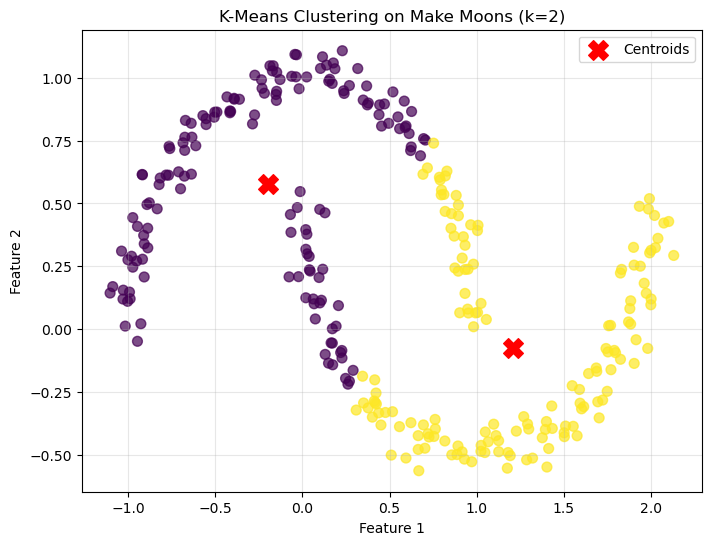

In [3]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans

# Generate the data
X, y_true = make_moons(n_samples=300, noise=0.05, random_state=42)

# Run K-Means with 2 clusters
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X)

# Plot the results
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, cmap='viridis', alpha=0.7, s=50)

# Plot the cluster centers
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            c='red', marker='X', s=200, label='Centroids')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('K-Means Clustering on Make Moons (k=2)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### PCA codes

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


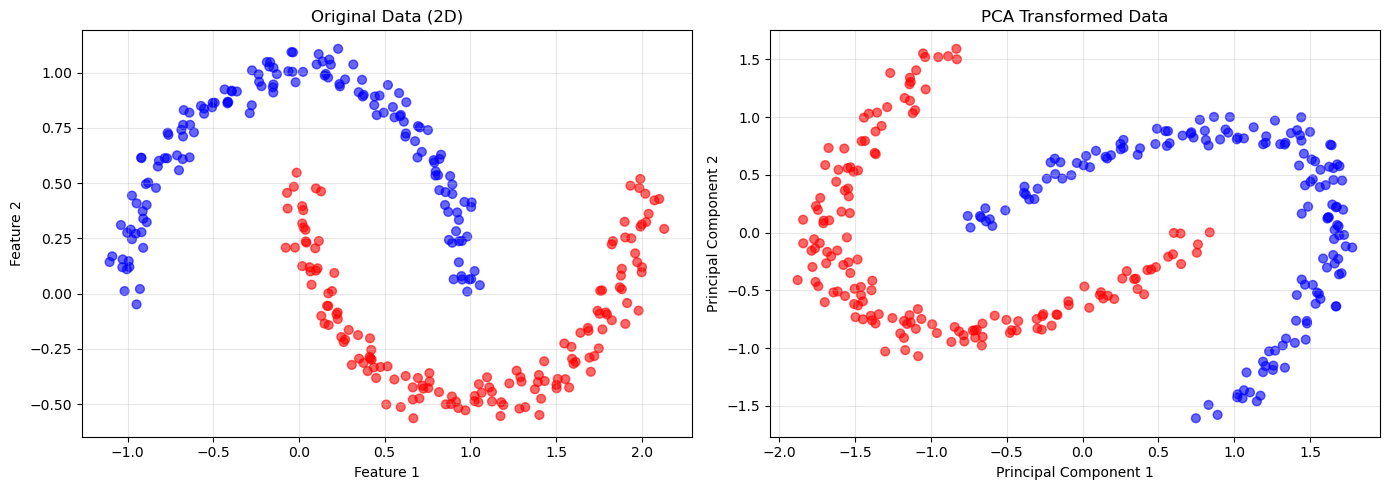

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Generate the data
X, y_true = make_moons(n_samples=300, noise=0.05, random_state=42)

# Standardize the data (important for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Plot original vs PCA-transformed
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original data
axes[0].scatter(X[:, 0], X[:, 1], c=y_true, cmap='bwr', alpha=0.6, s=40)
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')
axes[0].set_title('Original Data (2D)')
axes[0].grid(True, alpha=0.3)

# PCA-transformed data
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap='bwr', alpha=0.6, s=40)
axes[1].set_xlabel('Principal Component 1')
axes[1].set_ylabel('Principal Component 2')
axes[1].set_title('PCA Transformed Data')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

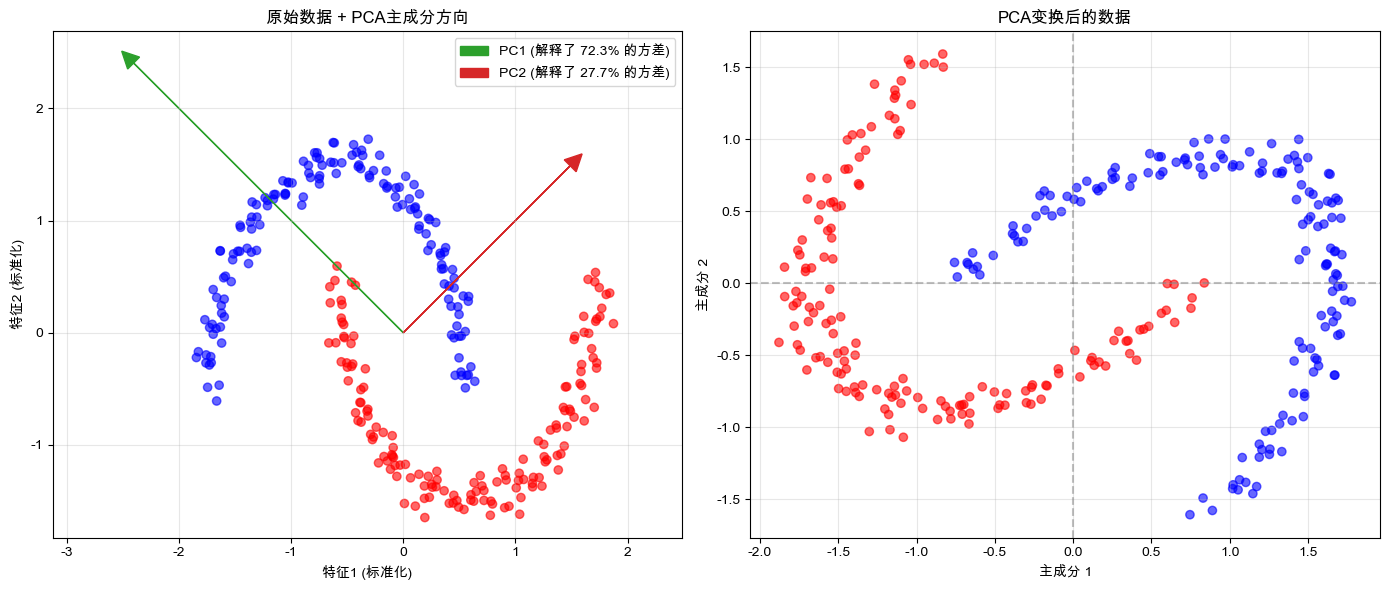

PC1解释的方差: 72.30%
PC2解释的方差: 27.70%
总共解释的方差: 100.00%


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ====== 解决中文显示问题 ======
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'PingFang SC', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False
# =============================

# 生成数据
X, y = make_moons(n_samples=300, noise=0.05, random_state=42)

# 标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 绘图
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 原始数据 + PCA方向
axes[0].scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='bwr', alpha=0.6)
axes[0].set_xlabel('特征1 (标准化)')
axes[0].set_ylabel('特征2 (标准化)')
axes[0].set_title('原始数据 + PCA主成分方向')
axes[0].grid(True, alpha=0.3)

# 画出PCA轴
mean = np.mean(X_scaled, axis=0)
for i, (comp, var) in enumerate(zip(pca.components_, pca.explained_variance_ratio_)):
    length = 2 * np.sqrt(var) * 2
    axes[0].arrow(mean[0], mean[1], comp[0]*length, comp[1]*length,
                  head_width=0.15, head_length=0.15, 
                  fc=f'C{i+2}', ec=f'C{i+2}', 
                  label=f'PC{i+1} (解释了 {var:.1%} 的方差)')

axes[0].legend()
axes[0].axis('equal')

# PCA变换后的数据
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='bwr', alpha=0.6)
axes[1].set_xlabel('主成分 1')
axes[1].set_ylabel('主成分 2')
axes[1].set_title('PCA变换后的数据')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[1].axvline(x=0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"PC1解释的方差: {pca.explained_variance_ratio_[0]:.2%}")
print(f"PC2解释的方差: {pca.explained_variance_ratio_[1]:.2%}")
print(f"总共解释的方差: {sum(pca.explained_variance_ratio_):.2%}")

In [9]:
# ========== 1. SVD 降维（用 NumPy 和 Scikit-learn） ==========
import numpy as np
import pandas as pd
from sklearn.decomposition import TruncatedSVD
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt

# ---- 1.1 用 NumPy 做完整 SVD ----
# 生成一个随机矩阵 (5行4列)
A = np.random.randn(5, 4)
print("原始矩阵 A (5x4):\n", A.round(2))

# 完整 SVD 分解
U, S, Vt = np.linalg.svd(A, full_matrices=False)
print("\nU (左奇异向量):\n", U.round(2))
print("S (奇异值):", S.round(2))
print("Vt (右奇异向量):\n", Vt.round(2))

# 重构矩阵（取前 k 个奇异值做近似）
k = 2  # 降到 2 维
U_k = U[:, :k]
S_k = np.diag(S[:k])
Vt_k = Vt[:k, :]
A_reconstructed = U_k @ S_k @ Vt_k
print("\n降维后重构的矩阵 (取前2个奇异值):\n", A_reconstructed.round(2))

# ---- 1.2 用 Scikit-learn 做截断 SVD（大规模数据推荐） ----
# 使用手写数字数据集做演示
digits = load_digits()
X = digits.data  # (1797, 64)
print(f"\n原始数据形状: {X.shape}")

# 降到 20 维
svd = TruncatedSVD(n_components=20, random_state=42)
X_reduced = svd.fit_transform(X)
print(f"降维后形状: {X_reduced.shape}")
print(f"前20个奇异值: {svd.singular_values_.round(2)}")
print(f"累计解释方差比: {svd.explained_variance_ratio_.cumsum()[-1]:.2%}")

原始矩阵 A (5x4):
 [[-0.51  1.97 -1.85  0.35]
 [ 0.1  -0.52  0.44  0.86]
 [ 0.6   0.81  1.56 -0.62]
 [ 0.7  -0.37 -1.49  0.35]
 [ 1.04  1.    1.87  0.67]]

U (左奇异向量):
 [[-0.56  0.79 -0.02 -0.19]
 [ 0.12 -0.18 -0.5  -0.53]
 [ 0.47  0.33  0.3   0.47]
 [-0.36 -0.12 -0.61  0.69]
 [ 0.57  0.46 -0.54 -0.03]]
S (奇异值): [3.54 2.45 1.49 1.  ]
Vt (右奇异向量):
 [[ 0.26 -0.02  0.96 -0.03]
 [ 0.07  1.    0.01  0.07]
 [-0.57  0.1   0.13 -0.8 ]
 [ 0.78 -0.01 -0.23 -0.59]]

降维后重构的矩阵 (取前2个奇异值):
 [[-0.38  1.97 -1.89  0.21]
 [ 0.08 -0.45  0.42 -0.05]
 [ 0.49  0.77  1.61  0.  ]
 [-0.35 -0.28 -1.22  0.02]
 [ 0.61  1.07  1.97  0.01]]

原始数据形状: (1797, 64)
降维后形状: (1797, 20)
前20个奇异值: [2193.12  567.    542.    504.15  425.59  353.22  320.38  302.07  279.56
  268.52  228.66  224.16  207.6   197.01  185.79  174.75  170.85  165.45
  148.27  144.93]
累计解释方差比: 89.41%


In [10]:
# ========== 2. NMF 非负矩阵分解 ==========
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import CountVectorizer

# ---- 2.1 用 NMF 提取图像特征（人脸/数字） ----
# 用前面的手写数字数据
nmf = NMF(n_components=20, init='random', random_state=42)
W = nmf.fit_transform(X)  # W: (1797, 20)，每个样本在20个主题上的权重
H = nmf.components_       # H: (20, 64)，每个主题对应的特征

print(f"NMF 分解后 W 的形状: {W.shape}")
print(f"NMF 分解后 H 的形状: {H.shape}")

# ---- 2.2 用 NMF 做文本主题建模（LDA 的替代方案） ----
# 构造简单的文档-词频矩阵
corpus = [
    "machine learning is great",
    "deep learning and neural networks",
    "data science with python",
    "artificial intelligence and machine learning",
    "statistics and probability",
    "python programming for data science"
]

vectorizer = CountVectorizer(stop_words='english')
X_text = vectorizer.fit_transform(corpus)  # (6, 14)
feature_names = vectorizer.get_feature_names_out()

# NMF 提取 3 个主题
nmf_text = NMF(n_components=3, random_state=42)
W_text = nmf_text.fit_transform(X_text)
H_text = nmf_text.components_

# 打印每个主题的 top 关键词
print("\n========== NMF 文本主题建模 ==========")
for topic_idx, topic in enumerate(H_text):
    top_features = [feature_names[i] for i in topic.argsort()[-5:][::-1]]
    print(f"主题 {topic_idx+1}: {' | '.join(top_features)}")

NMF 分解后 W 的形状: (1797, 20)
NMF 分解后 H 的形状: (20, 64)

========== NMF 文本主题建模 ==========
主题 1: science | python | data | programming | statistics
主题 2: machine | learning | intelligence | artificial | great
主题 3: learning | neural | networks | deep | great


/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/decomposition/_nmf.py:1759: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


In [16]:
# ========== 3. FunkSVD（推荐系统协同过滤） ==========
# 用 Surprise 库（专门做推荐系统的库，需要 pip install scikit-surprise）
# 如果没有装，先运行：pip install scikit-surprise
!pip install scikit-surprise
from surprise import SVD, Dataset, Reader
from surprise.model_selection import cross_validate, train_test_split
from surprise import accuracy
import pandas as pd

# ---- 3.1 加载内置数据集（MovieLens 100K） ----
# 如果你没有网络，可以跳过这一步，用下面的模拟数据
try:
    data = Dataset.load_builtin('ml-100k')
    print("成功加载 MovieLens 100K 数据集")
    
    # 使用 SVD（FunkSVD 的经典实现）
    algo = SVD(n_factors=100, n_epochs=20, lr_all=0.005, reg_all=0.4, random_state=42)
    
    # 交叉验证
    results = cross_validate(algo, data, measures=['RMSE', 'MAE'], cv=5, verbose=True)
    print(f"\n平均 RMSE: {results['test_rmse'].mean():.4f}")
    print(f"平均 MAE:  {results['test_mae'].mean():.4f}")
    
except:
    print("无法加载内置数据，使用模拟数据演示")
    # ---- 3.2 模拟数据演示 ----
    # 构造用户-物品评分数据（user_id, item_id, rating）
    ratings_dict = {
        'user_id': [1, 1, 1, 2, 2, 3, 3, 4, 4, 4],
        'item_id': [1, 2, 3, 1, 3, 2, 3, 1, 2, 3],
        'rating':  [5, 4, 3, 4, 5, 2, 3, 5, 4, 2]
    }
    df = pd.DataFrame(ratings_dict)
    print("模拟评分矩阵:\n", df)
    
    # 加载到 Surprise
    reader = Reader(rating_scale=(1, 5))
    data = Dataset.load_from_df(df[['user_id', 'item_id', 'rating']], reader)
    
    # 训练/测试分割
    trainset, testset = train_test_split(data, test_size=0.2, random_state=42)
    
    # 训练 SVD
    algo = SVD(n_factors=5, n_epochs=10, lr_all=0.005, reg_all=0.4, random_state=42)
    algo.fit(trainset)
    
    # 预测
    predictions = algo.test(testset)
    print(f"\nRMSE: {accuracy.rmse(predictions):.4f}")
    
    # ---- 3.3 给某个用户做推荐 ----
    user_id = 1
    all_items = set([1, 2, 3, 4, 5])
    rated_items = set(df[df['user_id'] == user_id]['item_id'])
    unrated = all_items - rated_items
    
    print(f"\n用户 {user_id} 未评分的物品: {unrated}")
    for item in unrated:
        pred = algo.predict(user_id, item)
        print(f"  预测评分 for 物品 {item}: {pred.est:.2f}")

成功加载 MovieLens 100K 数据集
Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.9474  0.9646  0.9499  0.9543  0.9653  0.9563  0.0074  
MAE (testset)     0.7584  0.7752  0.7583  0.7652  0.7720  0.7658  0.0069  
Fit time          0.22    0.24    0.22    0.22    0.21    0.22    0.01    
Test time         0.07    0.03    0.02    0.02    0.06    0.04    0.02    

平均 RMSE: 0.9563
平均 MAE:  0.7658


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import sys
import json

### features of array

In [49]:
a = [1,2,3,4,5,10,11,12,13,13,14,14,1,1,2,1111111199993,4,3333333333333, 33333,21,25,1224,124,12]
b = np.array(a)

print(a)
print(b)


[1, 2, 3, 4, 5, 10, 11, 12, 13, 13, 14, 14, 1, 1, 2, 1111111199993, 4, 3333333333333, 33333, 21, 25, 1224, 124, 12]
[            1             2             3             4             5
            10            11            12            13            13
            14            14             1             1             2
 1111111199993             4 3333333333333         33333            21
            25          1224           124            12]


#### 小

In [50]:
sys.getsizeof(a), sys.getsizeof(b)

(248, 304)

### example of k-means

In [20]:
np.random.seed(0)

In [22]:
x = np.array([4,5,10,2,3,11,2,12])
y = np.array([21,19,17,12,22,12,12,13])

len(x), len(y)

(8, 8)

In [25]:
x.shape

(8,)

In [23]:
data = np.array([x,y])
data.shape

(2, 8)

In [24]:
data

array([[ 4,  5, 10,  2,  3, 11,  2, 12],
       [21, 19, 17, 12, 22, 12, 12, 13]])

In [ ]:
k = 2

In [51]:
means = data[:, np.random.choice(range(len(x)), size=k, replace=False)]
means.shape

(2, 2)

In [52]:
means

array([[ 2, 10],
       [12, 17]])

(k means code)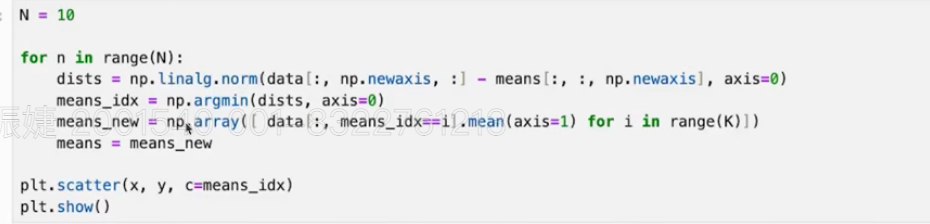